# Shortest Path / Depth Scaling

This notebook compares plain SFT against `Aux (lambda=0.1)` across all trained depths `2/4/6/10/14` using the saved metrics from the training notebooks.


In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
personal_token = user_secrets.get_secret("GITHUB_TOKEN")

!rm -rf transformer-analyzing
!git clone https://{personal_token}@github.com/maximvw/transformer-analyzing.git transformer-analyzing
%cd transformer-analyzing

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

PYTHON = sys.executable
print("Python:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name} | {props.total_memory / 1e9:.1f} GB")

ROOT = Path.cwd()
print("ROOT:", ROOT)

CKPT_DIR = ROOT / "checkpoints" / "shortest_path_dijkstra_full_n10"
print("CKPT_DIR:", CKPT_DIR)


Cloning into 'transformer-analyzing'...
remote: Enumerating objects: 561, done.
remote: Counting objects: 100% (223/223), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 561 (delta 85), reused 164 (delta 48), pack-reused 338 (from 1)
Receiving objects: 100% (561/561), 17.71 MiB | 25.01 MiB/s, done.
Resolving deltas: 100% (232/232), done.
/kaggle/working/transformer-analyzing
Python: /usr/bin/python3
CUDA available: False
CUDA devices: 0
ROOT: /kaggle/working/transformer-analyzing
CKPT_DIR: /kaggle/working/transformer-analyzing/checkpoints/shortest_path_dijkstra_full_n10


## Checkpoints bootstrap

Run the next cell if you want to restore the saved Kaggle artifacts and plot training curves from `train_log.json`. The quality graphs below do not depend on this step.


In [2]:
!gdown https://drive.google.com/uc?id=1rxwEQq-8QW5gN0lGKsksKGI9A3hkdhj- -O checkpoints.zip
!unzip -o checkpoints.zip


Downloading...
From (original): https://drive.google.com/uc?id=1rxwEQq-8QW5gN0lGKsksKGI9A3hkdhj-
From (redirected): https://drive.google.com/uc?id=1rxwEQq-8QW5gN0lGKsksKGI9A3hkdhj-&confirm=t&uuid=66a20f15-63b6-4ddb-9331-84350e3e9277
To: /kaggle/working/transformer-analyzing/checkpoints.zip
100%|████████████████████████████████████████| 346M/346M [00:06<00:00, 54.0MB/s]
Archive:  checkpoints.zip
   creating: checkpoints/
  inflating: checkpoints/.DS_Store   
  inflating: __MACOSX/checkpoints/._.DS_Store  
   creating: checkpoints/shortest_path_dijkstra_full_n10/
  inflating: __MACOSX/checkpoints/._shortest_path_dijkstra_full_n10  
   creating: checkpoints/shortest_path_dijkstra_full_n10/dijkstra_aux_4L_lambda0.1/
  inflating: __MACOSX/checkpoints/shortest_path_dijkstra_full_n10/._dijkstra_aux_4L_lambda0.1  
   creating: checkpoints/shortest_path_dijkstra_full_n10/dijkstra_sft_4L/
  inflating: __MACOSX/checkpoints/shortest_path_dijkstra_full_n10/._dijkstra_sft_4L  
   creating: checkpoin

## Training curves

These plots are built from the saved `train_log.json` files in the downloaded checkpoint folders.


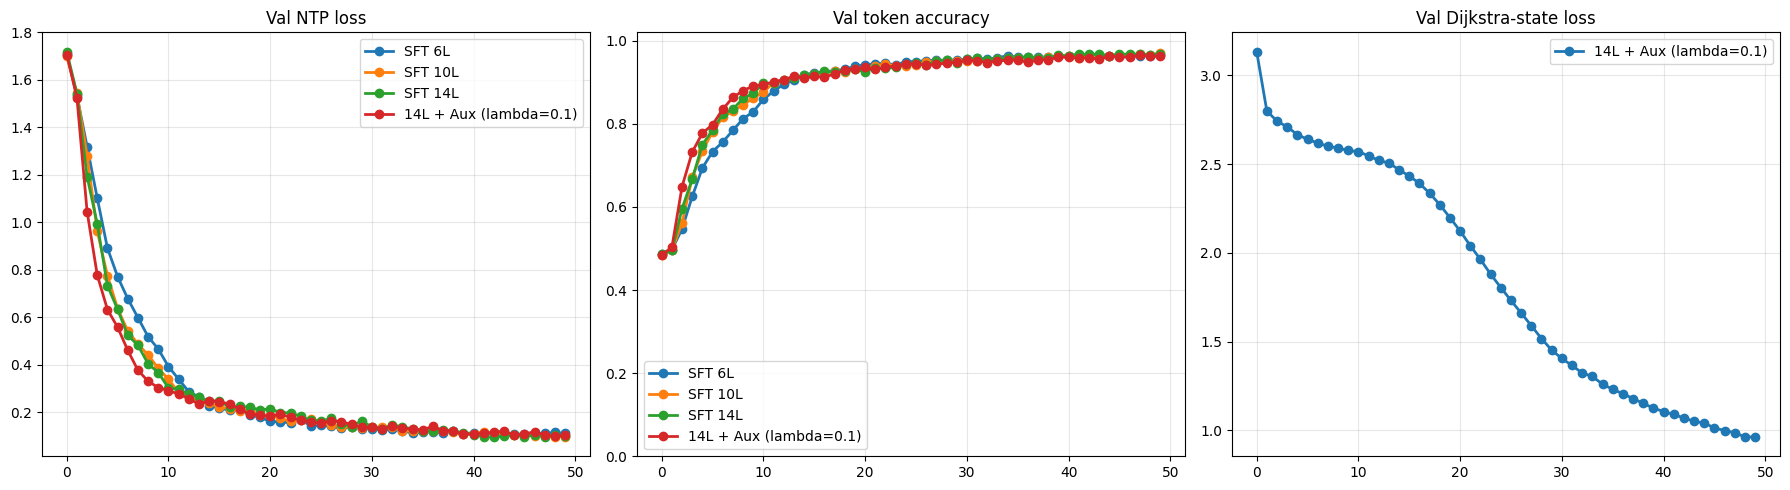

In [3]:
def load_log(path: Path):
    with open(path) as f:
        return json.load(f)

selected_for_curves = [
    "SFT 6L",
    "SFT 10L",
    "SFT 14L",
    "14L + Aux (lambda=0.1)",
]


def checkpoint_subdir(model_name: str) -> str:
    if model_name.startswith("SFT "):
        depth = model_name.split()[1].replace("L", "")
        return f"dijkstra_sft_{depth}L"
    depth = model_name.split("L", 1)[0]
    lam = model_name.split("lambda=")[1].rstrip(")")
    return f"dijkstra_aux_{depth}L_lambda{lam}"


logs = {}
missing_logs = []
for model_name in selected_for_curves:
    log_path = CKPT_DIR / checkpoint_subdir(model_name) / "train_log.json"
    if log_path.exists():
        logs[model_name] = load_log(log_path)
    else:
        missing_logs.append(str(log_path))

if missing_logs:
    raise FileNotFoundError("Missing train logs:\n" + "\n".join(missing_logs))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for label, log in logs.items():
    epochs = [row["epoch"] for row in log]
    axes[0].plot(epochs, [row["val"]["loss_main"] for row in log], marker="o", linewidth=2, label=label)
    axes[1].plot(epochs, [row["val"]["token_accuracy"] for row in log], marker="o", linewidth=2, label=label)
    if any(row["val"]["loss_state"] > 0 for row in log):
        axes[2].plot(epochs, [row["val"]["loss_state"] for row in log], marker="o", linewidth=2, label=label)

axes[0].set_title("Val NTP loss")
axes[1].set_title("Val token accuracy")
axes[1].set_ylim(0.0, 1.02)
axes[2].set_title("Val Dijkstra-state loss")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


In [4]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

split_order = ['test_id', 'test_ood_dense', 'test_ood_long_chain', 'test_ood_adversarial_direct', 'test_ood_equal_ties', 'test_ood_layered_bipartite', 'test_ood_near_complete_hidden_path']
split_labels = {'test_id': 'ID', 'test_ood_dense': 'Dense', 'test_ood_long_chain': 'Long chain', 'test_ood_adversarial_direct': 'Adv. direct', 'test_ood_equal_ties': 'Equal ties', 'test_ood_layered_bipartite': 'Layered bipartite', 'test_ood_near_complete_hidden_path': 'Hidden path'}

embedded_rows = [
  {
    "model": "SFT 2L",
    "depth": 2,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_id",
    "exact_match": 0.5055,
    "distance_accuracy": 0.9058,
    "token_accuracy": 0.9269
  },
  {
    "model": "SFT 2L",
    "depth": 2,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_dense",
    "exact_match": 0.661,
    "distance_accuracy": 0.9527,
    "token_accuracy": 0.9615
  },
  {
    "model": "SFT 2L",
    "depth": 2,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.0575,
    "distance_accuracy": 0.6614,
    "token_accuracy": 0.7985
  },
  {
    "model": "SFT 2L",
    "depth": 2,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.014,
    "distance_accuracy": 0.6076,
    "token_accuracy": 0.7831
  },
  {
    "model": "SFT 2L",
    "depth": 2,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9895,
    "distance_accuracy": 0.999,
    "token_accuracy": 0.999
  },
  {
    "model": "SFT 2L",
    "depth": 2,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.8655,
    "distance_accuracy": 0.986,
    "token_accuracy": 0.9873
  },
  {
    "model": "SFT 2L",
    "depth": 2,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0055,
    "distance_accuracy": 0.5533,
    "token_accuracy": 0.7574
  },
  {
    "model": "2L + Aux (lambda=0.1)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_id",
    "exact_match": 0.1535,
    "distance_accuracy": 0.7889,
    "token_accuracy": 0.8256
  },
  {
    "model": "2L + Aux (lambda=0.1)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_dense",
    "exact_match": 0.318,
    "distance_accuracy": 0.8767,
    "token_accuracy": 0.8936
  },
  {
    "model": "2L + Aux (lambda=0.1)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_long_chain",
    "exact_match": 0.0115,
    "distance_accuracy": 0.5736,
    "token_accuracy": 0.7178
  },
  {
    "model": "2L + Aux (lambda=0.1)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.0015,
    "distance_accuracy": 0.4929,
    "token_accuracy": 0.6823
  },
  {
    "model": "2L + Aux (lambda=0.1)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_equal_ties",
    "exact_match": 0.831,
    "distance_accuracy": 0.9816,
    "token_accuracy": 0.9835
  },
  {
    "model": "2L + Aux (lambda=0.1)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.5715,
    "distance_accuracy": 0.9494,
    "token_accuracy": 0.9536
  },
  {
    "model": "2L + Aux (lambda=0.1)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.003,
    "distance_accuracy": 0.5609,
    "token_accuracy": 0.7144
  },
  {
    "model": "2L + Aux (lambda=1.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_id",
    "exact_match": 0.0935,
    "distance_accuracy": 0.7492,
    "token_accuracy": 0.7883
  },
  {
    "model": "2L + Aux (lambda=1.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_dense",
    "exact_match": 0.1865,
    "distance_accuracy": 0.8313,
    "token_accuracy": 0.8601
  },
  {
    "model": "2L + Aux (lambda=1.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.006,
    "distance_accuracy": 0.5416,
    "token_accuracy": 0.6684
  },
  {
    "model": "2L + Aux (lambda=1.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.0115,
    "distance_accuracy": 0.5537,
    "token_accuracy": 0.7311
  },
  {
    "model": "2L + Aux (lambda=1.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.7325,
    "distance_accuracy": 0.9695,
    "token_accuracy": 0.972
  },
  {
    "model": "2L + Aux (lambda=1.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.3075,
    "distance_accuracy": 0.9043,
    "token_accuracy": 0.9126
  },
  {
    "model": "2L + Aux (lambda=1.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.002,
    "distance_accuracy": 0.5141,
    "token_accuracy": 0.679
  },
  {
    "model": "2L + Aux (lambda=10.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_id",
    "exact_match": 0.002,
    "distance_accuracy": 0.5529,
    "token_accuracy": 0.5993
  },
  {
    "model": "2L + Aux (lambda=10.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_dense",
    "exact_match": 0.0105,
    "distance_accuracy": 0.6585,
    "token_accuracy": 0.7008
  },
  {
    "model": "2L + Aux (lambda=10.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.0,
    "distance_accuracy": 0.4024,
    "token_accuracy": 0.4943
  },
  {
    "model": "2L + Aux (lambda=10.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.0,
    "distance_accuracy": 0.4339,
    "token_accuracy": 0.5603
  },
  {
    "model": "2L + Aux (lambda=10.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.073,
    "distance_accuracy": 0.791,
    "token_accuracy": 0.7884
  },
  {
    "model": "2L + Aux (lambda=10.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.027,
    "distance_accuracy": 0.7549,
    "token_accuracy": 0.7752
  },
  {
    "model": "2L + Aux (lambda=10.0)",
    "depth": 2,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0,
    "distance_accuracy": 0.4637,
    "token_accuracy": 0.5753
  },
  {
    "model": "SFT 4L",
    "depth": 4,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_id",
    "exact_match": 0.672,
    "distance_accuracy": 0.944,
    "token_accuracy": 0.9521
  },
  {
    "model": "SFT 4L",
    "depth": 4,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_dense",
    "exact_match": 0.8375,
    "distance_accuracy": 0.9793,
    "token_accuracy": 0.9817
  },
  {
    "model": "SFT 4L",
    "depth": 4,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.101,
    "distance_accuracy": 0.7158,
    "token_accuracy": 0.79
  },
  {
    "model": "SFT 4L",
    "depth": 4,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.022,
    "distance_accuracy": 0.6129,
    "token_accuracy": 0.7055
  },
  {
    "model": "SFT 4L",
    "depth": 4,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9995,
    "distance_accuracy": 1.0,
    "token_accuracy": 1.0
  },
  {
    "model": "SFT 4L",
    "depth": 4,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.9895,
    "distance_accuracy": 0.999,
    "token_accuracy": 0.999
  },
  {
    "model": "SFT 4L",
    "depth": 4,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0035,
    "distance_accuracy": 0.5644,
    "token_accuracy": 0.6211
  },
  {
    "model": "4L + Aux (lambda=0.1)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_id",
    "exact_match": 0.535,
    "distance_accuracy": 0.9161,
    "token_accuracy": 0.9324
  },
  {
    "model": "4L + Aux (lambda=0.1)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_dense",
    "exact_match": 0.713,
    "distance_accuracy": 0.9615,
    "token_accuracy": 0.9675
  },
  {
    "model": "4L + Aux (lambda=0.1)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_long_chain",
    "exact_match": 0.0675,
    "distance_accuracy": 0.6705,
    "token_accuracy": 0.8024
  },
  {
    "model": "4L + Aux (lambda=0.1)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.014,
    "distance_accuracy": 0.6128,
    "token_accuracy": 0.7794
  },
  {
    "model": "4L + Aux (lambda=0.1)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9725,
    "distance_accuracy": 0.9972,
    "token_accuracy": 0.9975
  },
  {
    "model": "4L + Aux (lambda=0.1)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.9725,
    "distance_accuracy": 0.9972,
    "token_accuracy": 0.9975
  },
  {
    "model": "4L + Aux (lambda=0.1)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0075,
    "distance_accuracy": 0.6176,
    "token_accuracy": 0.7551
  },
  {
    "model": "4L + Aux (lambda=1.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_id",
    "exact_match": 0.5065,
    "distance_accuracy": 0.9127,
    "token_accuracy": 0.9282
  },
  {
    "model": "4L + Aux (lambda=1.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_dense",
    "exact_match": 0.6545,
    "distance_accuracy": 0.9532,
    "token_accuracy": 0.9604
  },
  {
    "model": "4L + Aux (lambda=1.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.0715,
    "distance_accuracy": 0.6789,
    "token_accuracy": 0.7992
  },
  {
    "model": "4L + Aux (lambda=1.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.043,
    "distance_accuracy": 0.6668,
    "token_accuracy": 0.8016
  },
  {
    "model": "4L + Aux (lambda=1.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.979,
    "distance_accuracy": 0.9979,
    "token_accuracy": 0.9981
  },
  {
    "model": "4L + Aux (lambda=1.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.779,
    "distance_accuracy": 0.9755,
    "token_accuracy": 0.9778
  },
  {
    "model": "4L + Aux (lambda=1.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0135,
    "distance_accuracy": 0.614,
    "token_accuracy": 0.7546
  },
  {
    "model": "4L + Aux (lambda=10.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_id",
    "exact_match": 0.1685,
    "distance_accuracy": 0.7964,
    "token_accuracy": 0.8222
  },
  {
    "model": "4L + Aux (lambda=10.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_dense",
    "exact_match": 0.434,
    "distance_accuracy": 0.9124,
    "token_accuracy": 0.9234
  },
  {
    "model": "4L + Aux (lambda=10.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.0065,
    "distance_accuracy": 0.5732,
    "token_accuracy": 0.6447
  },
  {
    "model": "4L + Aux (lambda=10.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.007,
    "distance_accuracy": 0.5675,
    "token_accuracy": 0.6976
  },
  {
    "model": "4L + Aux (lambda=10.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.968,
    "distance_accuracy": 0.9968,
    "token_accuracy": 0.997
  },
  {
    "model": "4L + Aux (lambda=10.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.7525,
    "distance_accuracy": 0.973,
    "token_accuracy": 0.9754
  },
  {
    "model": "4L + Aux (lambda=10.0)",
    "depth": 4,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.005,
    "distance_accuracy": 0.6166,
    "token_accuracy": 0.7022
  },
  {
    "model": "SFT 6L",
    "depth": 6,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_id",
    "exact_match": 0.7075,
    "distance_accuracy": 0.9516,
    "token_accuracy": 0.9611
  },
  {
    "model": "SFT 6L",
    "depth": 6,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_dense",
    "exact_match": 0.862,
    "distance_accuracy": 0.9835,
    "token_accuracy": 0.9853
  },
  {
    "model": "SFT 6L",
    "depth": 6,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.1655,
    "distance_accuracy": 0.7537,
    "token_accuracy": 0.85
  },
  {
    "model": "SFT 6L",
    "depth": 6,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.1015,
    "distance_accuracy": 0.7433,
    "token_accuracy": 0.8437
  },
  {
    "model": "SFT 6L",
    "depth": 6,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9755,
    "distance_accuracy": 0.9972,
    "token_accuracy": 0.9975
  },
  {
    "model": "SFT 6L",
    "depth": 6,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.9725,
    "distance_accuracy": 0.9972,
    "token_accuracy": 0.9975
  },
  {
    "model": "SFT 6L",
    "depth": 6,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0385,
    "distance_accuracy": 0.7096,
    "token_accuracy": 0.7934
  },
  {
    "model": "6L + Aux (lambda=0.1)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_id",
    "exact_match": 0.6995,
    "distance_accuracy": 0.952,
    "token_accuracy": 0.957
  },
  {
    "model": "6L + Aux (lambda=0.1)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_dense",
    "exact_match": 0.873,
    "distance_accuracy": 0.9847,
    "token_accuracy": 0.9862
  },
  {
    "model": "6L + Aux (lambda=0.1)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_long_chain",
    "exact_match": 0.1535,
    "distance_accuracy": 0.7629,
    "token_accuracy": 0.7913
  },
  {
    "model": "6L + Aux (lambda=0.1)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.021,
    "distance_accuracy": 0.6348,
    "token_accuracy": 0.6687
  },
  {
    "model": "6L + Aux (lambda=0.1)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9875,
    "distance_accuracy": 0.9988,
    "token_accuracy": 0.9989
  },
  {
    "model": "6L + Aux (lambda=0.1)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.9595,
    "distance_accuracy": 0.9959,
    "token_accuracy": 0.9962
  },
  {
    "model": "6L + Aux (lambda=0.1)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.005,
    "distance_accuracy": 0.5792,
    "token_accuracy": 0.6165
  },
  {
    "model": "6L + Aux (lambda=1.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_id",
    "exact_match": 0.6345,
    "distance_accuracy": 0.9407,
    "token_accuracy": 0.9516
  },
  {
    "model": "6L + Aux (lambda=1.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_dense",
    "exact_match": 0.8245,
    "distance_accuracy": 0.977,
    "token_accuracy": 0.9801
  },
  {
    "model": "6L + Aux (lambda=1.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.097,
    "distance_accuracy": 0.7022,
    "token_accuracy": 0.8245
  },
  {
    "model": "6L + Aux (lambda=1.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.0475,
    "distance_accuracy": 0.664,
    "token_accuracy": 0.8143
  },
  {
    "model": "6L + Aux (lambda=1.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9725,
    "distance_accuracy": 0.997,
    "token_accuracy": 0.9971
  },
  {
    "model": "6L + Aux (lambda=1.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.967,
    "distance_accuracy": 0.9967,
    "token_accuracy": 0.997
  },
  {
    "model": "6L + Aux (lambda=1.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.008,
    "distance_accuracy": 0.6188,
    "token_accuracy": 0.7552
  },
  {
    "model": "6L + Aux (lambda=10.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_id",
    "exact_match": 0.035,
    "distance_accuracy": 0.6849,
    "token_accuracy": 0.7232
  },
  {
    "model": "6L + Aux (lambda=10.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_dense",
    "exact_match": 0.114,
    "distance_accuracy": 0.7965,
    "token_accuracy": 0.8237
  },
  {
    "model": "6L + Aux (lambda=10.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.001,
    "distance_accuracy": 0.505,
    "token_accuracy": 0.6012
  },
  {
    "model": "6L + Aux (lambda=10.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.001,
    "distance_accuracy": 0.4589,
    "token_accuracy": 0.6226
  },
  {
    "model": "6L + Aux (lambda=10.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.1045,
    "distance_accuracy": 0.8511,
    "token_accuracy": 0.8656
  },
  {
    "model": "6L + Aux (lambda=10.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.117,
    "distance_accuracy": 0.8416,
    "token_accuracy": 0.8567
  },
  {
    "model": "6L + Aux (lambda=10.0)",
    "depth": 6,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.001,
    "distance_accuracy": 0.4935,
    "token_accuracy": 0.5862
  },
  {
    "model": "SFT 10L",
    "depth": 10,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_id",
    "exact_match": 0.753,
    "distance_accuracy": 0.96,
    "token_accuracy": 0.9655
  },
  {
    "model": "SFT 10L",
    "depth": 10,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_dense",
    "exact_match": 0.892,
    "distance_accuracy": 0.9872,
    "token_accuracy": 0.9885
  },
  {
    "model": "SFT 10L",
    "depth": 10,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.213,
    "distance_accuracy": 0.7957,
    "token_accuracy": 0.837
  },
  {
    "model": "SFT 10L",
    "depth": 10,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.074,
    "distance_accuracy": 0.7187,
    "token_accuracy": 0.7521
  },
  {
    "model": "SFT 10L",
    "depth": 10,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9995,
    "distance_accuracy": 1.0,
    "token_accuracy": 1.0
  },
  {
    "model": "SFT 10L",
    "depth": 10,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.9845,
    "distance_accuracy": 0.9984,
    "token_accuracy": 0.9986
  },
  {
    "model": "SFT 10L",
    "depth": 10,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0305,
    "distance_accuracy": 0.7167,
    "token_accuracy": 0.7507
  },
  {
    "model": "10L + Aux (lambda=0.1)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_id",
    "exact_match": 0.6565,
    "distance_accuracy": 0.9429,
    "token_accuracy": 0.949
  },
  {
    "model": "10L + Aux (lambda=0.1)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_dense",
    "exact_match": 0.783,
    "distance_accuracy": 0.9716,
    "token_accuracy": 0.9746
  },
  {
    "model": "10L + Aux (lambda=0.1)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_long_chain",
    "exact_match": 0.1575,
    "distance_accuracy": 0.7491,
    "token_accuracy": 0.7816
  },
  {
    "model": "10L + Aux (lambda=0.1)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.039,
    "distance_accuracy": 0.6844,
    "token_accuracy": 0.7202
  },
  {
    "model": "10L + Aux (lambda=0.1)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_equal_ties",
    "exact_match": 0.971,
    "distance_accuracy": 0.997,
    "token_accuracy": 0.9972
  },
  {
    "model": "10L + Aux (lambda=0.1)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.9625,
    "distance_accuracy": 0.9962,
    "token_accuracy": 0.9965
  },
  {
    "model": "10L + Aux (lambda=0.1)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0015,
    "distance_accuracy": 0.6068,
    "token_accuracy": 0.648
  },
  {
    "model": "10L + Aux (lambda=1.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_id",
    "exact_match": 0.6555,
    "distance_accuracy": 0.9414,
    "token_accuracy": 0.9503
  },
  {
    "model": "10L + Aux (lambda=1.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_dense",
    "exact_match": 0.849,
    "distance_accuracy": 0.9807,
    "token_accuracy": 0.983
  },
  {
    "model": "10L + Aux (lambda=1.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.205,
    "distance_accuracy": 0.782,
    "token_accuracy": 0.862
  },
  {
    "model": "10L + Aux (lambda=1.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.0305,
    "distance_accuracy": 0.637,
    "token_accuracy": 0.74
  },
  {
    "model": "10L + Aux (lambda=1.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9995,
    "distance_accuracy": 1.0,
    "token_accuracy": 1.0
  },
  {
    "model": "10L + Aux (lambda=1.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.972,
    "distance_accuracy": 0.9972,
    "token_accuracy": 0.9975
  },
  {
    "model": "10L + Aux (lambda=1.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.017,
    "distance_accuracy": 0.6592,
    "token_accuracy": 0.7231
  },
  {
    "model": "10L + Aux (lambda=10.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_id",
    "exact_match": 0.244,
    "distance_accuracy": 0.8391,
    "token_accuracy": 0.8607
  },
  {
    "model": "10L + Aux (lambda=10.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_dense",
    "exact_match": 0.473,
    "distance_accuracy": 0.9238,
    "token_accuracy": 0.9332
  },
  {
    "model": "10L + Aux (lambda=10.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.012,
    "distance_accuracy": 0.5961,
    "token_accuracy": 0.6745
  },
  {
    "model": "10L + Aux (lambda=10.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.0165,
    "distance_accuracy": 0.6515,
    "token_accuracy": 0.734
  },
  {
    "model": "10L + Aux (lambda=10.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.897,
    "distance_accuracy": 0.9895,
    "token_accuracy": 0.9903
  },
  {
    "model": "10L + Aux (lambda=10.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.695,
    "distance_accuracy": 0.9664,
    "token_accuracy": 0.9692
  },
  {
    "model": "10L + Aux (lambda=10.0)",
    "depth": 10,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.003,
    "distance_accuracy": 0.5959,
    "token_accuracy": 0.6746
  },
  {
    "model": "SFT 14L",
    "depth": 14,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_id",
    "exact_match": 0.754,
    "distance_accuracy": 0.9608,
    "token_accuracy": 0.9647
  },
  {
    "model": "SFT 14L",
    "depth": 14,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_dense",
    "exact_match": 0.81,
    "distance_accuracy": 0.9761,
    "token_accuracy": 0.9781
  },
  {
    "model": "SFT 14L",
    "depth": 14,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.183,
    "distance_accuracy": 0.7765,
    "token_accuracy": 0.801
  },
  {
    "model": "SFT 14L",
    "depth": 14,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.0735,
    "distance_accuracy": 0.7255,
    "token_accuracy": 0.7539
  },
  {
    "model": "SFT 14L",
    "depth": 14,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.983,
    "distance_accuracy": 0.9983,
    "token_accuracy": 0.9985
  },
  {
    "model": "SFT 14L",
    "depth": 14,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.988,
    "distance_accuracy": 0.9988,
    "token_accuracy": 0.9989
  },
  {
    "model": "SFT 14L",
    "depth": 14,
    "family": "SFT",
    "lambda_state": 0.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0,
    "distance_accuracy": 0.4925,
    "token_accuracy": 0.5386
  },
  {
    "model": "14L + Aux (lambda=0.1)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_id",
    "exact_match": 0.7215,
    "distance_accuracy": 0.9559,
    "token_accuracy": 0.961
  },
  {
    "model": "14L + Aux (lambda=0.1)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_dense",
    "exact_match": 0.877,
    "distance_accuracy": 0.9852,
    "token_accuracy": 0.9869
  },
  {
    "model": "14L + Aux (lambda=0.1)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_long_chain",
    "exact_match": 0.211,
    "distance_accuracy": 0.7869,
    "token_accuracy": 0.8183
  },
  {
    "model": "14L + Aux (lambda=0.1)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.084,
    "distance_accuracy": 0.7431,
    "token_accuracy": 0.7827
  },
  {
    "model": "14L + Aux (lambda=0.1)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_equal_ties",
    "exact_match": 0.9975,
    "distance_accuracy": 0.9998,
    "token_accuracy": 0.9998
  },
  {
    "model": "14L + Aux (lambda=0.1)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.98,
    "distance_accuracy": 0.998,
    "token_accuracy": 0.9982
  },
  {
    "model": "14L + Aux (lambda=0.1)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 0.1,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.036,
    "distance_accuracy": 0.7368,
    "token_accuracy": 0.7678
  },
  {
    "model": "14L + Aux (lambda=1.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_id",
    "exact_match": 0.7265,
    "distance_accuracy": 0.9574,
    "token_accuracy": 0.9625
  },
  {
    "model": "14L + Aux (lambda=1.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_dense",
    "exact_match": 0.89,
    "distance_accuracy": 0.9862,
    "token_accuracy": 0.9877
  },
  {
    "model": "14L + Aux (lambda=1.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.189,
    "distance_accuracy": 0.7805,
    "token_accuracy": 0.8293
  },
  {
    "model": "14L + Aux (lambda=1.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.03,
    "distance_accuracy": 0.6432,
    "token_accuracy": 0.7147
  },
  {
    "model": "14L + Aux (lambda=1.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.923,
    "distance_accuracy": 0.9919,
    "token_accuracy": 0.9926
  },
  {
    "model": "14L + Aux (lambda=1.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.972,
    "distance_accuracy": 0.9972,
    "token_accuracy": 0.9974
  },
  {
    "model": "14L + Aux (lambda=1.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 1.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0315,
    "distance_accuracy": 0.6551,
    "token_accuracy": 0.7007
  },
  {
    "model": "14L + Aux (lambda=10.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_id",
    "exact_match": 0.3165,
    "distance_accuracy": 0.8669,
    "token_accuracy": 0.8819
  },
  {
    "model": "14L + Aux (lambda=10.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_dense",
    "exact_match": 0.632,
    "distance_accuracy": 0.9499,
    "token_accuracy": 0.9552
  },
  {
    "model": "14L + Aux (lambda=10.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_long_chain",
    "exact_match": 0.0155,
    "distance_accuracy": 0.63,
    "token_accuracy": 0.6858
  },
  {
    "model": "14L + Aux (lambda=10.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_adversarial_direct",
    "exact_match": 0.0055,
    "distance_accuracy": 0.5833,
    "token_accuracy": 0.6672
  },
  {
    "model": "14L + Aux (lambda=10.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_equal_ties",
    "exact_match": 0.939,
    "distance_accuracy": 0.9936,
    "token_accuracy": 0.9941
  },
  {
    "model": "14L + Aux (lambda=10.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_layered_bipartite",
    "exact_match": 0.8165,
    "distance_accuracy": 0.9805,
    "token_accuracy": 0.9822
  },
  {
    "model": "14L + Aux (lambda=10.0)",
    "depth": 14,
    "family": "Aux",
    "lambda_state": 10.0,
    "split": "test_ood_near_complete_hidden_path",
    "exact_match": 0.0035,
    "distance_accuracy": 0.6319,
    "token_accuracy": 0.684
  }
]

df_all = pd.DataFrame(embedded_rows)
df_all["split"] = pd.Categorical(df_all["split"], categories=split_order, ordered=True)

print("Rows:", len(df_all))
df_all.head()


Rows: 140


,model,depth,family,lambda_state,split,exact_match,distance_accuracy,token_accuracy
0,SFT 2L,2,SFT,0.0,test_id,0.5055,0.9058,0.9269
1,SFT 2L,2,SFT,0.0,test_ood_dense,0.6610,0.9527,0.9615
2,SFT 2L,2,SFT,0.0,test_ood_long_chain,0.0575,0.6614,0.7985
3,SFT 2L,2,SFT,0.0,test_ood_adversarial_direct,0.0140,0.6076,0.7831
4,SFT 2L,2,SFT,0.0,test_ood_equal_ties,0.9895,0.9990,0.9990


In [5]:
selected_models = [
    "SFT 2L",
    "SFT 4L",
    "SFT 6L",
    "SFT 10L",
    "SFT 14L",
    "2L + Aux (lambda=0.1)",
    "4L + Aux (lambda=0.1)",
    "6L + Aux (lambda=0.1)",
    "10L + Aux (lambda=0.1)",
    "14L + Aux (lambda=0.1)",
]

bridge_df = df_all[df_all["model"].isin(selected_models)].copy()
bridge_df["regime"] = np.where(bridge_df["family"] == "SFT", "SFT", "Aux 0.1")

summary_rows = []
for depth in sorted(bridge_df["depth"].unique()):
    for regime in ["SFT", "Aux 0.1"]:
        part = bridge_df[(bridge_df["depth"] == depth) & (bridge_df["regime"] == regime)]
        summary_rows.append(
            {
                "depth": depth,
                "regime": regime,
                "ID exact match": part.loc[part["split"] == "test_id", "exact_match"].iloc[0],
                "Mean OOD exact": part.loc[part["split"] != "test_id", "exact_match"].mean(),
            }
        )

summary_df = pd.DataFrame(summary_rows)
summary_df


,depth,regime,ID exact match,Mean OOD exact
0,2,SFT,0.5055,0.432167
1,2,Aux 0.1,0.1535,0.289417
2,4,SFT,0.6720,0.492167
3,4,Aux 0.1,0.5350,0.457833
4,6,SFT,0.7075,0.519250
5,6,Aux 0.1,0.6995,0.499917
6,10,SFT,0.7530,0.532250
7,10,Aux 0.1,0.6565,0.485750
8,14,SFT,0.7540,0.506250
9,14,Aux 0.1,0.7215,0.530917


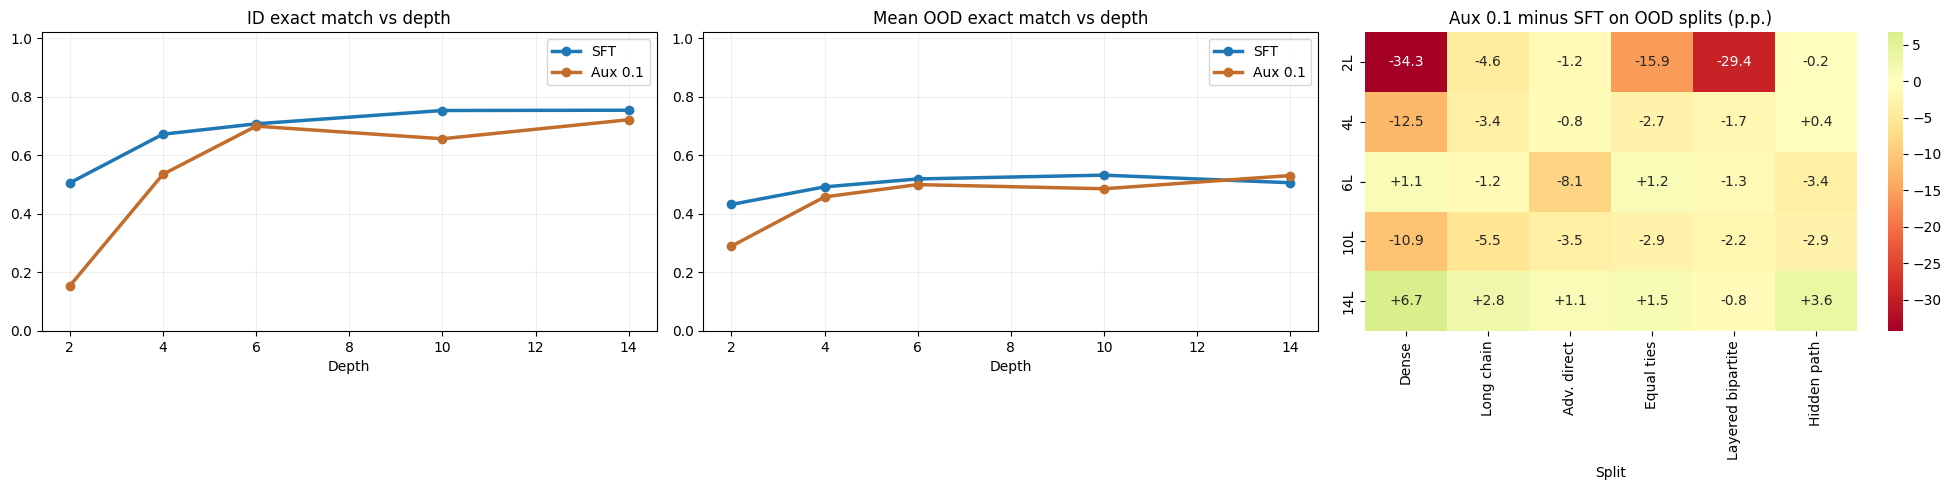

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for regime, color in [("SFT", "#1f77b4"), ("Aux 0.1", "#c26d2b")]:
    part = summary_df[summary_df["regime"] == regime].sort_values("depth")
    axes[0].plot(part["depth"], part["ID exact match"], marker="o", linewidth=2.5, color=color, label=regime)
    axes[1].plot(part["depth"], part["Mean OOD exact"], marker="o", linewidth=2.5, color=color, label=regime)

axes[0].set_title("ID exact match vs depth")
axes[1].set_title("Mean OOD exact match vs depth")
for ax in axes[:2]:
    ax.set_xlabel("Depth")
    ax.set_ylim(0.0, 1.02)
    ax.grid(alpha=0.2)
    ax.legend()

ood_splits = [split for split in split_order if split != "test_id"]
delta_rows = []
for depth in sorted(bridge_df["depth"].unique()):
    sft = bridge_df[(bridge_df["depth"] == depth) & (bridge_df["family"] == "SFT")].set_index("split")
    aux = bridge_df[(bridge_df["depth"] == depth) & (bridge_df["lambda_state"] == 0.1)].set_index("split")
    delta_rows.append(
        {
            "Depth": f"{depth}L",
            **{split_labels[split]: (aux.loc[split, "exact_match"] - sft.loc[split, "exact_match"]) * 100 for split in ood_splits},
        }
    )

delta_df = pd.DataFrame(delta_rows).set_index("Depth")
sns.heatmap(delta_df, annot=True, fmt="+.1f", cmap="RdYlGn", center=0.0, ax=axes[2])
axes[2].set_title("Aux 0.1 minus SFT on OOD splits (p.p.)")
axes[2].set_xlabel("Split")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()
